Case Study of Cyclistic by Kevin Simckes

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
#uplaoding a file
from google.colab import files
uploaded = files.upload()

Saving Divvy_Trips_2019_Q1.csv to Divvy_Trips_2019_Q1 (2).csv
Saving Divvy_Trips_2020_Q1.csv to Divvy_Trips_2020_Q1 (1).csv


In [ ]:
# Upload Divvy datasets (csv files)
q1_2019 = pd.read_csv("Divvy_Trips_2019_Q1.csv")
q1_2020 = pd.read_csv("Divvy_Trips_2020_Q1.csv")

In [ ]:
# Comparing column names for each of the files
print("Columns for Q1 2019:\n", q1_2019.columns)
print("\nColumns for Q1 2020:\n", q1_2020.columns)

Columns for Q1 2019:
 Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')

Columns for Q1 2020:
 Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')


In [ ]:
# Renaming columns to make them consistent with q1_2020
q1_2019 = q1_2019.rename(columns={
'trip_id': 'ride_id',
'bikeid': 'rideable_type',
'start_time': 'started_at',
'end_time': 'ended_at',
'from_station_name': 'start_station_name',
'from_station_id': 'start_station_id',
'to_station_name': 'end_station_name',
'to_station_id': 'end_station_id',
'usertype': 'member_casual'
})

In [ ]:
# Inspect the data frames and look for incongruities
print("\nQ1 2019 Data Info:")
q1_2019.info()
print("\nQ1 2020 Data Info:")
q1_2020.info()


Q1 2019 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             365069 non-null  int64  
 1   started_at          365069 non-null  object 
 2   ended_at            365069 non-null  object 
 3   rideable_type       365069 non-null  int64  
 4   tripduration        365069 non-null  object 
 5   start_station_id    365069 non-null  int64  
 6   start_station_name  365069 non-null  object 
 7   end_station_id      365069 non-null  int64  
 8   end_station_name    365069 non-null  object 
 9   member_casual       365069 non-null  object 
 10  gender              345358 non-null  object 
 11  birthyear           347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB

Q1 2020 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data col

In [ ]:
# Converting ride_id and rideable_type to string so that they can stack
# correctly
q1_2019['ride_id'] = q1_2019['ride_id'].astype(str)
q1_2019['rideable_type'] = q1_2019['rideable_type'].astype(str)

In [ ]:
# Stack individual quarter's data frames into one big data frame
all_trips = pd.concat([q1_2019, q1_2020], ignore_index=True)

In [ ]:
# Removing lat, long, birthyear, and gender fields from Q1 2019 as this data
# was dropped beginning in 2020
# The 'errors="ignore"' argument is used here to prevent an error if a column
# is not found
all_trips = all_trips.drop(columns=['start_lat', 'start_lng', 'end_lat',
                                    'end_lng', 'birthyear', 'gender',
'tripduration'], errors='ignore')

In [ ]:
# Inspecting the new table that has been created
print("\nList of column names:\n", all_trips.columns)
print("\nHow many rows are in data frame?", len(all_trips))
print("\nDimensions of the data frame:", all_trips.shape)
print("\nSee the first 5 rows of data frame:\n", all_trips.head())
print("\nSee list of columns and data types:\n")
all_trips.info()


List of column names:
 Index(['ride_id', 'started_at', 'ended_at', 'rideable_type',
       'start_station_id', 'start_station_name', 'end_station_id',
       'end_station_name', 'member_casual'],
      dtype='object')

How many rows are in data frame? 791956

Dimensions of the data frame: (791956, 9)

See the first 5 rows of data frame:
     ride_id           started_at             ended_at rideable_type  \
0  21742443  2019-01-01 00:04:37  2019-01-01 00:11:07          2167   
1  21742444  2019-01-01 00:08:13  2019-01-01 00:15:34          4386   
2  21742445  2019-01-01 00:13:23  2019-01-01 00:27:12          1524   
3  21742446  2019-01-01 00:13:45  2019-01-01 00:43:28           252   
4  21742447  2019-01-01 00:14:52  2019-01-01 00:20:56          1170   

   start_station_id                   start_station_name  end_station_id  \
0               199               Wabash Ave & Grand Ave            84.0   
1                44               State St & Randolph St           624.0   
2   

In [ ]:
# Statistical summary of data (mainly for numerics)
print("\nStatistical summary of data:\n", all_trips.describe())


Statistical summary of data:
        start_station_id  end_station_id
count     791956.000000   791955.000000
mean         204.400294      204.379354
std          158.919132      159.323552
min            2.000000        2.000000
25%           77.000000       77.000000
50%          174.000000      174.000000
75%          291.000000      291.000000
max          675.000000      675.000000


In [ ]:
# there is inconsistency in the member_casual column I will begin by discovering
# how many observations fall under each usertype
print("\nValue counts for 'member_casual' column before cleaning:\n",
all_trips['member_casual'].value_counts())


Value counts for 'member_casual' column before cleaning:
 member_casual
member        378407
Subscriber    341906
casual         48480
Customer       23163
Name: count, dtype: int64


In [ ]:
# Replacing subscriber with member and customer with casual and member to maintain
# consistency in the user type column member_casual

all_trips['member_casual'] = all_trips['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

# Verify the changes
print(all_trips['member_casual'].value_counts())

member_casual
member    720313
casual     71643
Name: count, dtype: int64


In [ ]:
# creating additional aggregation points by adding day, month and year columns
# beginning with Converting 'started_at' and 'ended_at' to datetime objects
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

In [ ]:
# Extract day, month, and year from 'started_at'
all_trips['date'] = all_trips['started_at'].dt.date
all_trips['day'] = all_trips['started_at'].dt.day
all_trips['month'] = all_trips['started_at'].dt.month
all_trips['year'] = all_trips['started_at'].dt.year
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()

In [ ]:
# Display the first few rows with the new columns
print(all_trips[['started_at', 'date', 'day', 'month', 'year', 'day_of_week']].head())

           started_at        date  day  month  year day_of_week
0 2019-01-01 00:04:37  2019-01-01    1      1  2019     Tuesday
1 2019-01-01 00:08:13  2019-01-01    1      1  2019     Tuesday
2 2019-01-01 00:13:23  2019-01-01    1      1  2019     Tuesday
3 2019-01-01 00:13:45  2019-01-01    1      1  2019     Tuesday
4 2019-01-01 00:14:52  2019-01-01    1      1  2019     Tuesday


In [ ]:
# Adding a "ride_length" calculation to all_trips which is the length of each trip in seconds
all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds()

In [ ]:
# Inspecting the structure of the columns
print("\nData types after adding date columns and ride_length:\n")
all_trips.info()


Data types after adding date columns and ride_length:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791956 non-null  object        
 1   started_at          791956 non-null  datetime64[ns]
 2   ended_at            791956 non-null  datetime64[ns]
 3   rideable_type       791956 non-null  object        
 4   start_station_id    791956 non-null  int64         
 5   start_station_name  791956 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   end_station_name    791955 non-null  object        
 8   member_casual       791956 non-null  object        
 9   date                791956 non-null  object        
 10  day                 791956 non-null  int32         
 11  month               791956 non-null  int32         
 12  year                791956 non

In [ ]:
# Removeing "bad" data
# The data frame includes entries where bikes were taken out of docks
# for quality checks or ride_length was negative
# Creating a new version of the data frame (v2) since data is being removed

all_trips_v2 = all_trips[(all_trips['start_station_name'] != "HQ QR") & (all_trips['ride_length'] >=
0)].copy()

# Check for duplicate rows
print(f"Number of duplicate rows in all_trips_v2: {all_trips_v2.duplicated().sum()}")

Number of duplicate rows in all_trips_v2: 0


In [ ]:
# Inspecting the structure of the columns
print("\nData types and shape after removing bad datah:\n")
all_trips_v2.info()


Data types and shape after removing bad datah:

<class 'pandas.core.frame.DataFrame'>
Index: 788189 entries, 0 to 791955
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             788189 non-null  object        
 1   started_at          788189 non-null  datetime64[ns]
 2   ended_at            788189 non-null  datetime64[ns]
 3   rideable_type       788189 non-null  object        
 4   start_station_id    788189 non-null  int64         
 5   start_station_name  788189 non-null  object        
 6   end_station_id      788189 non-null  float64       
 7   end_station_name    788189 non-null  object        
 8   member_casual       788189 non-null  object        
 9   date                788189 non-null  object        
 10  day                 788189 non-null  int32         
 11  month               788189 non-null  int32         
 12  year                788189 non-null  int32

In [ ]:
# Descriptive analysis on ride_length (all figures in seconds)
print("\nDescriptive statistics for ride_length:\n", all_trips_v2['ride_length'].describe())


Descriptive statistics for ride_length:
 count    7.881890e+05
mean     1.189459e+03
std      3.329191e+04
min      1.000000e+00
25%      3.310000e+02
50%      5.390000e+02
75%      9.120000e+02
max      1.063202e+07
Name: ride_length, dtype: float64


In [ ]:
#creating a new column of ride_length in minutes for easier interpretation

all_trips_v2['ride_length_minutes'] = all_trips_v2['ride_length'] / 60
print("First 5 rows with new 'ride_length_minutes' column:")
display(all_trips_v2[['ride_length', 'ride_length_minutes']].head())

First 5 rows with new 'ride_length_minutes' column:


,ride_length,ride_length_minutes
0,390.0,6.500000
1,441.0,7.350000
2,829.0,13.816667
3,1783.0,29.716667
4,364.0,6.066667


In [ ]:
# Descriptive analysis on ride_length_minutes (all figures in minutes)
print("\nDescriptive statistics for ride_length_minutes:\n", all_trips_v2['ride_length_minutes'].describe())


Descriptive statistics for ride_length_minutes:
 count    788189.000000
mean         19.824311
std         554.865218
min           0.016667
25%           5.516667
50%           8.983333
75%          15.200000
max      177200.366667
Name: ride_length_minutes, dtype: float64


The average ride is a short duration, however the std is also considerable

In [ ]:
# Compare members and casual users
print("\nRide length statistics grouped by member_casual:\n",
all_trips_v2.groupby('member_casual')['ride_length_minutes'].agg(['mean', 'median', 'max', 'min']))


Ride length statistics grouped by member_casual:
                     mean     median            max       min
member_casual                                               
casual         89.546398  23.216667  177200.366667  0.033333
member         13.254206   8.466667  101607.133333  0.016667


it seems here on first glance that casual riders ride for much longer than members

In [ ]:
# average ride time by each day for members vs casual users
print("\nAverage ride length by member type and day of the week:\n",
all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length_minutes'].mean())


Average ride length by member type and day of the week:
 member_casual  day_of_week
casual         Friday         101.512288
               Monday          79.200841
               Saturday        82.512847
               Sunday          84.355073
               Thursday       140.861114
               Tuesday         76.030064
               Wednesday       74.672874
member         Friday          13.278896
               Monday          13.705187
               Saturday        16.234549
               Sunday          16.215639
               Thursday        11.786821
               Tuesday         12.824027
               Wednesday       11.866397
Name: ride_length_minutes, dtype: float64


In [ ]:
# Order the days of the week for correct sorting for analysis
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'],
categories=days_order, ordered=True)

print("\nAverage ride length (sorted by day of week):\n", all_trips_v2.groupby(['member_casual',
'day_of_week'])['ride_length_minutes'].mean())


Average ride length (sorted by day of week):
 member_casual  day_of_week
casual         Sunday          84.355073
               Monday          79.200841
               Tuesday         76.030064
               Wednesday       74.672874
               Thursday       140.861114
               Friday         101.512288
               Saturday        82.512847
member         Sunday          16.215639
               Monday          13.705187
               Tuesday         12.824027
               Wednesday       11.866397
               Thursday        11.786821
               Friday          13.278896
               Saturday        16.234549
Name: ride_length_minutes, dtype: float64


/tmp/ipykernel_3420/3189305853.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nAverage ride length (sorted by day of week):\n", all_trips_v2.groupby(['member_casual',


In [ ]:
# Analyze ridership data by type and weekday
summary_stats = all_trips_v2.groupby(['member_casual', 'day_of_week'], observed=False).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('ride_length_minutes', 'mean')
).reset_index()

print("\nSummary of rides and duration by rider type and weekday:\n", summary_stats)


Summary of rides and duration by rider type and weekday:
    member_casual day_of_week  number_of_rides  average_duration
0         casual      Sunday            18652         84.355073
1         casual      Monday             5591         79.200841
2         casual     Tuesday             7311         76.030064
3         casual   Wednesday             7690         74.672874
4         casual    Thursday             7147        140.861114
5         casual      Friday             8013        101.512288
6         casual    Saturday            13473         82.512847
7         member      Sunday            60197         16.215639
8         member      Monday           110430         13.705187
9         member     Tuesday           127974         12.824027
10        member   Wednesday           121902         11.866397
11        member    Thursday           125228         11.786821
12        member      Friday           115168         13.278896
13        member    Saturday            59413

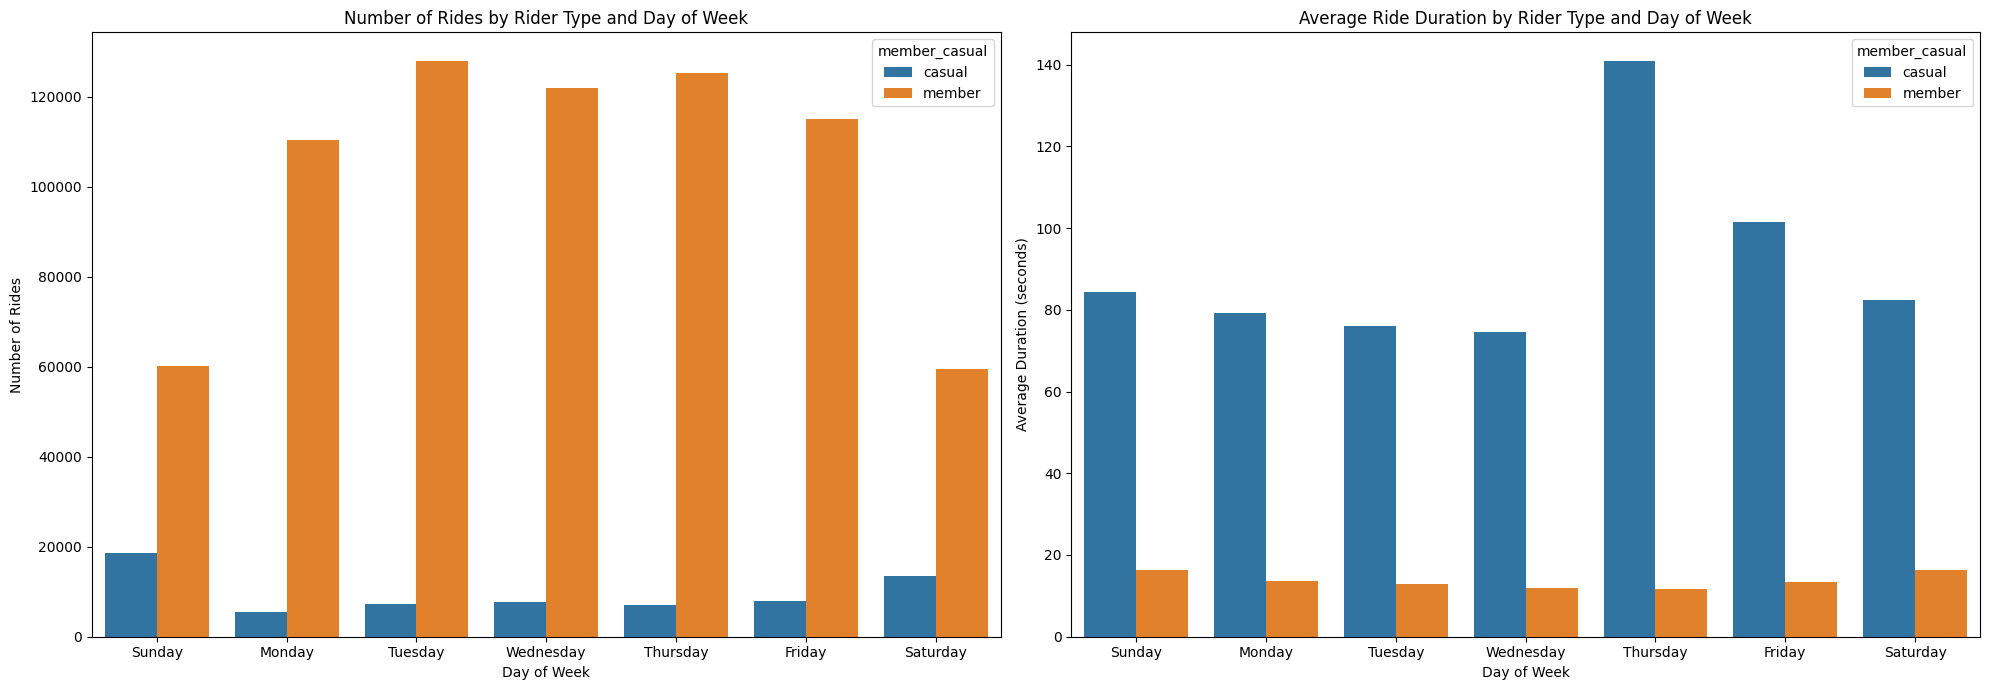

In [ ]:
# Create subplots for better comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plotting number of rides
sns.barplot(x='day_of_week', y='number_of_rides', hue='member_casual', data=summary_stats, ax=axes[0])
axes[0].set_title('Number of Rides by Rider Type and Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Rides')

# Plotting average ride duration
sns.barplot(x='day_of_week', y='average_duration', hue='member_casual', data=summary_stats, ax=axes[1])
axes[1].set_title('Average Ride Duration by Rider Type and Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Duration (seconds)')

plt.tight_layout()
plt.show()

members perform significantly more rides per day than casual riders, with monday-friday consistently higher that sunday/saturday. However, casual riders still ride for much longer. Perhaps members are utilizing the bikes for transportation to and from work rather than for casual use.

In [ ]:
print("Number of rides by rider type and weekday:\n", summary_stats[['member_casual', 'day_of_week', 'number_of_rides']])

Number of rides by rider type and weekday:
    member_casual day_of_week  number_of_rides
0         casual      Sunday            18652
1         casual      Monday             5591
2         casual     Tuesday             7311
3         casual   Wednesday             7690
4         casual    Thursday             7147
5         casual      Friday             8013
6         casual    Saturday            13473
7         member      Sunday            60197
8         member      Monday           110430
9         member     Tuesday           127974
10        member   Wednesday           121902
11        member    Thursday           125228
12        member      Friday           115168
13        member    Saturday            59413


In [ ]:
# changing the member_casual column back to usertype for more descriptive column name

all_trips_v2 = all_trips_v2.rename(columns={
'member_casual': 'usertype'
})

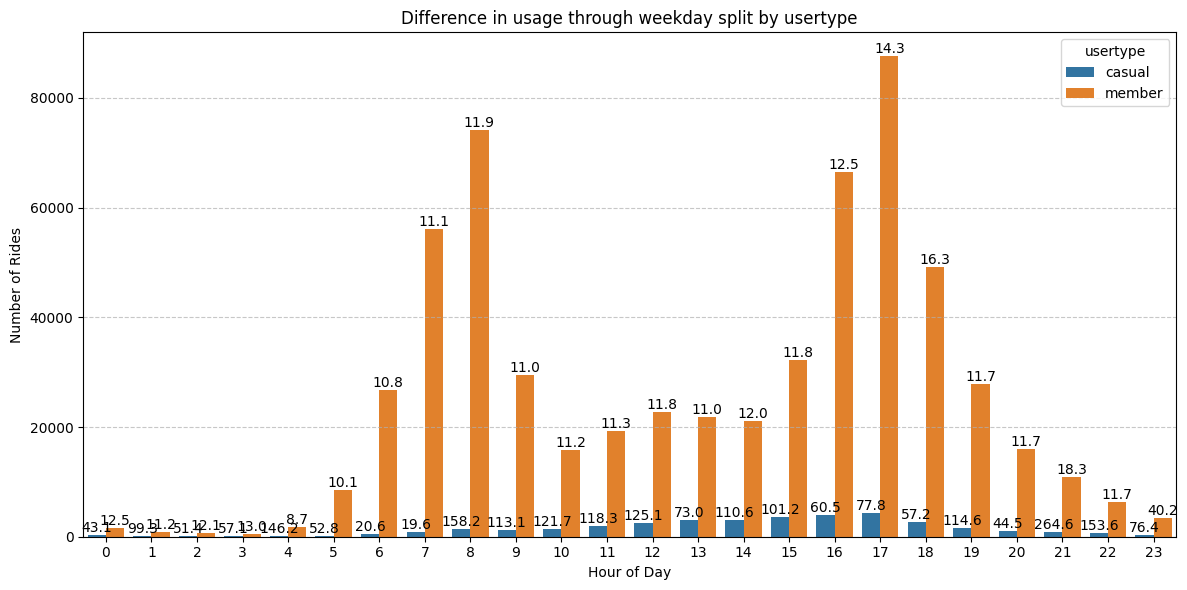

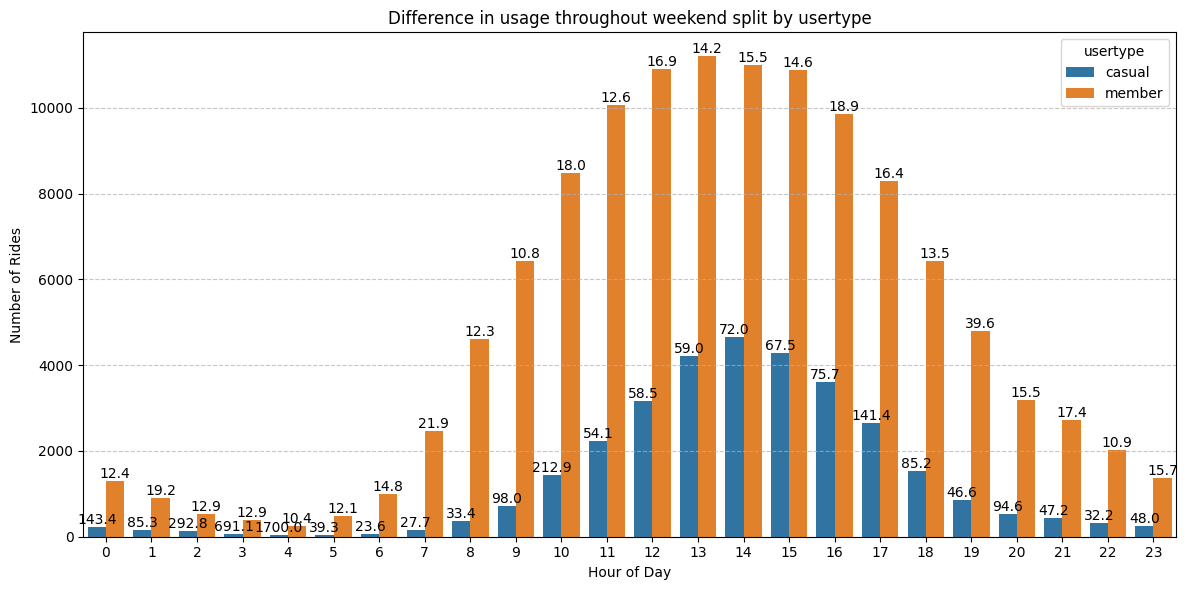

In [ ]:
#creating a comparison of the time of day for rides
# Ensure 'start_hour' is extracted from 'started_at' column.
all_trips_v2['start_hour'] = all_trips_v2['started_at'].dt.hour

# Define weekdays and weekends
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekends = ["Saturday", "Sunday"]

# --- Weekday Plot ---
# Filter data for weekdays
weekday_data = all_trips_v2[all_trips_v2['day_of_week'].isin(weekdays)]

# Group by hour and usertype, calculating number of rides and average duration in minutes
hourly_stats_weekdays = weekday_data.groupby(['start_hour', 'usertype']).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length_minutes', 'mean') # Using ride_length_minutes
).reset_index()

# Create the visualization for weekdays
plt.figure(figsize=(12, 6))
ax_weekday = sns.barplot(x='start_hour', y='number_of_rides', hue='usertype', data=hourly_stats_weekdays)
plt.title('Difference in usage through weekday split by usertype')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add average duration as label to each bar for weekdays
unique_usertypes_in_data_weekday = sorted(hourly_stats_weekdays['usertype'].unique())
for container_idx, container in enumerate(ax_weekday.containers):
    if container_idx < len(unique_usertypes_in_data_weekday):
        current_usertype = unique_usertypes_in_data_weekday[container_idx]
        labels_source_df = hourly_stats_weekdays[
            hourly_stats_weekdays['usertype'] == current_usertype
        ].sort_values(by='start_hour')
        labels_for_bars = labels_source_df['average_duration'].map('{:.1f}'.format).tolist()
        ax_weekday.bar_label(container, labels=labels_for_bars, label_type='edge')
    else:
        # This case should ideally not be reached if the number of containers matches unique hue values.
        # If it does, we can fall back to default labeling or print an error/warning.
        print(f"Warning: Container index {container_idx} out of bounds for unique usertypes: {unique_usertypes_in_data_weekday}")
        ax_weekday.bar_label(container, fmt='%.1f', label_type='edge') # Fallback to bar height label

plt.tight_layout()
plt.show()

# --- Weekend Plot ---
# Filter data for weekends
weekend_data = all_trips_v2[all_trips_v2['day_of_week'].isin(weekends)]

# Group by hour and usertype, calculating number of rides and average duration in minutes
hourly_stats_weekends = weekend_data.groupby(['start_hour', 'usertype']).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length_minutes', 'mean') # Using ride_length_minutes
).reset_index()

# Create the visualization for weekends
plt.figure(figsize=(12, 6))
ax_weekend = sns.barplot(x='start_hour', y='number_of_rides', hue='usertype', data=hourly_stats_weekends)
plt.title('Difference in usage throughout weekend split by usertype')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add average duration as label to each bar for weekends
unique_usertypes_in_data_weekend = sorted(hourly_stats_weekends['usertype'].unique())
for container_idx, container in enumerate(ax_weekend.containers):
    if container_idx < len(unique_usertypes_in_data_weekend):
        current_usertype = unique_usertypes_in_data_weekend[container_idx]
        labels_source_df = hourly_stats_weekends[
            hourly_stats_weekends['usertype'] == current_usertype
        ].sort_values(by='start_hour')
        labels_for_bars = labels_source_df['average_duration'].map('{:.1f}'.format).tolist()
        ax_weekend.bar_label(container, labels=labels_for_bars, label_type='edge')
    else:
        # This case should ideally not be reached if the number of containers matches unique hue values.
        # If it does, we can fall back to default labeling or print an error/warning.
        print(f"Warning: Container index {container_idx} out of bounds for unique usertypes: {unique_usertypes_in_data_weekend}")
        ax_weekend.bar_label(container, fmt='%.1f', label_type='edge') # Fallback to bar height label

plt.tight_layout()
plt.show()

In [ ]:
# removing the rideable type column and saving to new variable, for being unable to be properly merged to one dataset

all_trips_v3 = all_trips_v2.drop(columns=['rideable_type'])

In [ ]:
# exporting the cleaned and manipulated data for safekeeping
cleaned_data = all_trips_v3
cleaned_data.to_csv('cleaned_data.csv', index=False)
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>